In [1]:
# Import numerical and data handling libraries
import numpy as np
import pandas as pd

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Enable inline plotting in Jupyter Notebook
%matplotlib inline

# Format pandas output to show 3 decimal places
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Set default plot size for all matplotlib figures
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Load the NSL-KDD training dataset from CSV file
df_original = pd.read_csv(r"C:\Users\Prathap\Desktop\Infosys Project\SentinelNet\Dataset\nsl-kdd\KDDTrain+.txt")
# Create a copy to work with, keeping the original data intact
df = df_original.copy()

# Display the first 5 rows of the dataset
df.head()

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.070,0.070,0.000,0.000,0.000,0.000,1.000,1.000,neptune,21


In [4]:
# Define the list of column names based on the NSL-KDD dataset description
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'attack', 'level'
]

# Assign the column names to the dataframe
df.columns = columns

df.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,udp,other,SF,146,0,0,0,0,0,...,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.070,0.070,0.000,0.000,0.000,0.000,1.000,1.000,neptune,21


In [5]:
# Display basic information about the dataset:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null  int64  
 13 

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125972.000,287.147,2604.526,0.000,0.000,0.000,0.000,42908.000
src_bytes,125972.000,45567.101,5870354.481,0.000,0.000,44.000,276.000,1379963888.000
dst_bytes,125972.000,19779.271,4021285.112,0.000,0.000,0.000,516.000,1309937401.000
land,125972.000,0.000,0.014,0.000,0.000,0.000,0.000,1.000
wrong_fragment,125972.000,0.023,0.254,0.000,0.000,0.000,0.000,3.000
urgent,125972.000,0.000,0.014,0.000,0.000,0.000,0.000,3.000
hot,125972.000,0.204,2.150,0.000,0.000,0.000,0.000,77.000
num_failed_logins,125972.000,0.001,0.045,0.000,0.000,0.000,0.000,5.000
logged_in,125972.000,0.396,0.489,0.000,0.000,0.000,1.000,1.000
num_compromised,125972.000,0.279,23.942,0.000,0.000,0.000,0.000,7479.000


In [8]:
# Check for missing (null) values in each column
df.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [9]:
# Helper function to analyze unique values in specified columns
def unique_values(df, columns):
    """
    Prints unique values and their counts for each specified column in the DataFrame.
    
    Parameters:
    df (DataFrame): The input DataFrame to analyze.
    columns (list): A list of column names to inspect.
    """
    for column_name in columns:
        print(f"Column: {column_name}\n{'-'*30}")
        unique_vals = df[column_name].unique()
        value_counts = df[column_name].value_counts()
        
        print(f"Unique Values ({len(unique_vals)}): {unique_vals}\n")
        print(f"Value Counts:\n{value_counts}\n{'='*40}\n")

In [10]:
# Identify all categorical columns (object data type)
cat_features = df.select_dtypes(include='object').columns

unique_values(df, cat_features)

Column: protocol_type
------------------------------
Unique Values (3): ['udp' 'tcp' 'icmp']

Value Counts:
protocol_type
tcp     102688
udp      14993
icmp      8291
Name: count, dtype: int64

Column: service
------------------------------
Unique Values (70): ['other' 'private' 'http' 'remote_job' 'ftp_data' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']

Value Counts:
service
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6859
 

In [11]:
# Count the number of completely duplicated rows in the dataset
df.duplicated().sum()

np.int64(0)

In [12]:
# Get the shape of the dataset
df.shape

(125972, 43)

<Figure size 2000x4000 with 0 Axes>

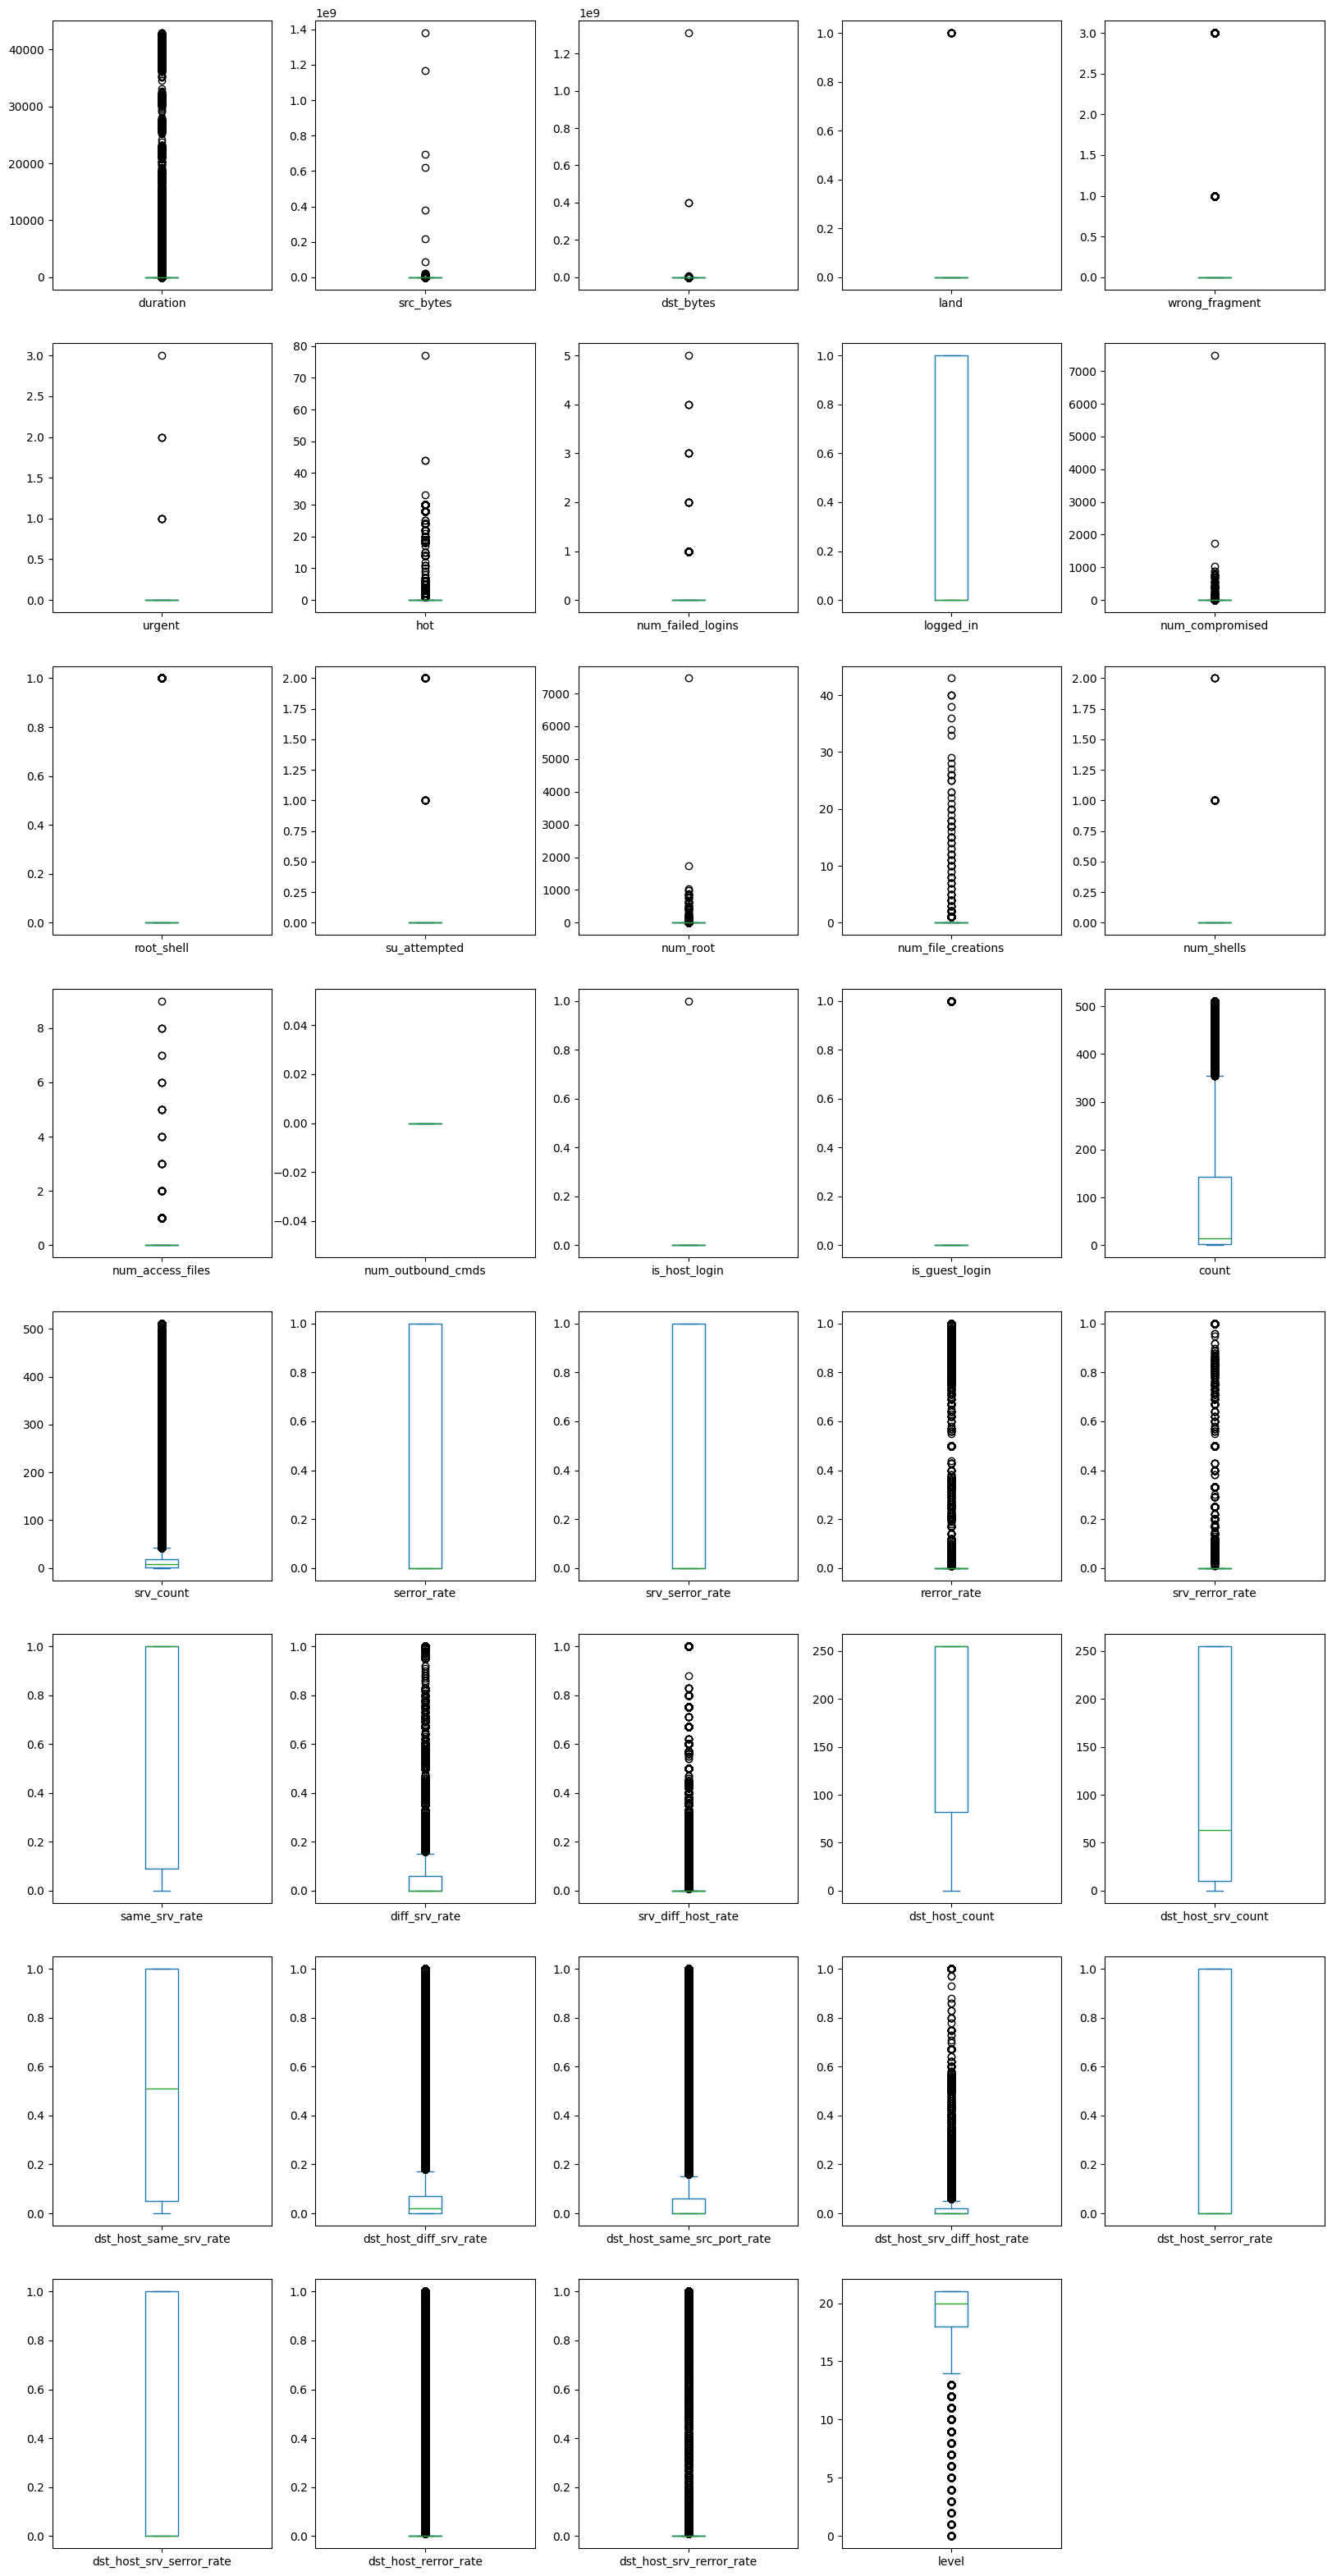

In [13]:
plt.figure(figsize=(20, 40))

# Create box plots for each feature as subplots
df.plot(
    kind='box',
    subplots=True,
    layout=(8, 5),   # 8 rows x 5 columns of subplots
    figsize=(20, 40) # Overall figure size
)

# Display the plots
plt.show()

In [14]:
# Convert the attack column to binary labels: 'normal' or 'attack'
df['attack'] = df['attack'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

In [15]:
df['attack'].unique()

array(['normal', 'attack'], dtype=object)

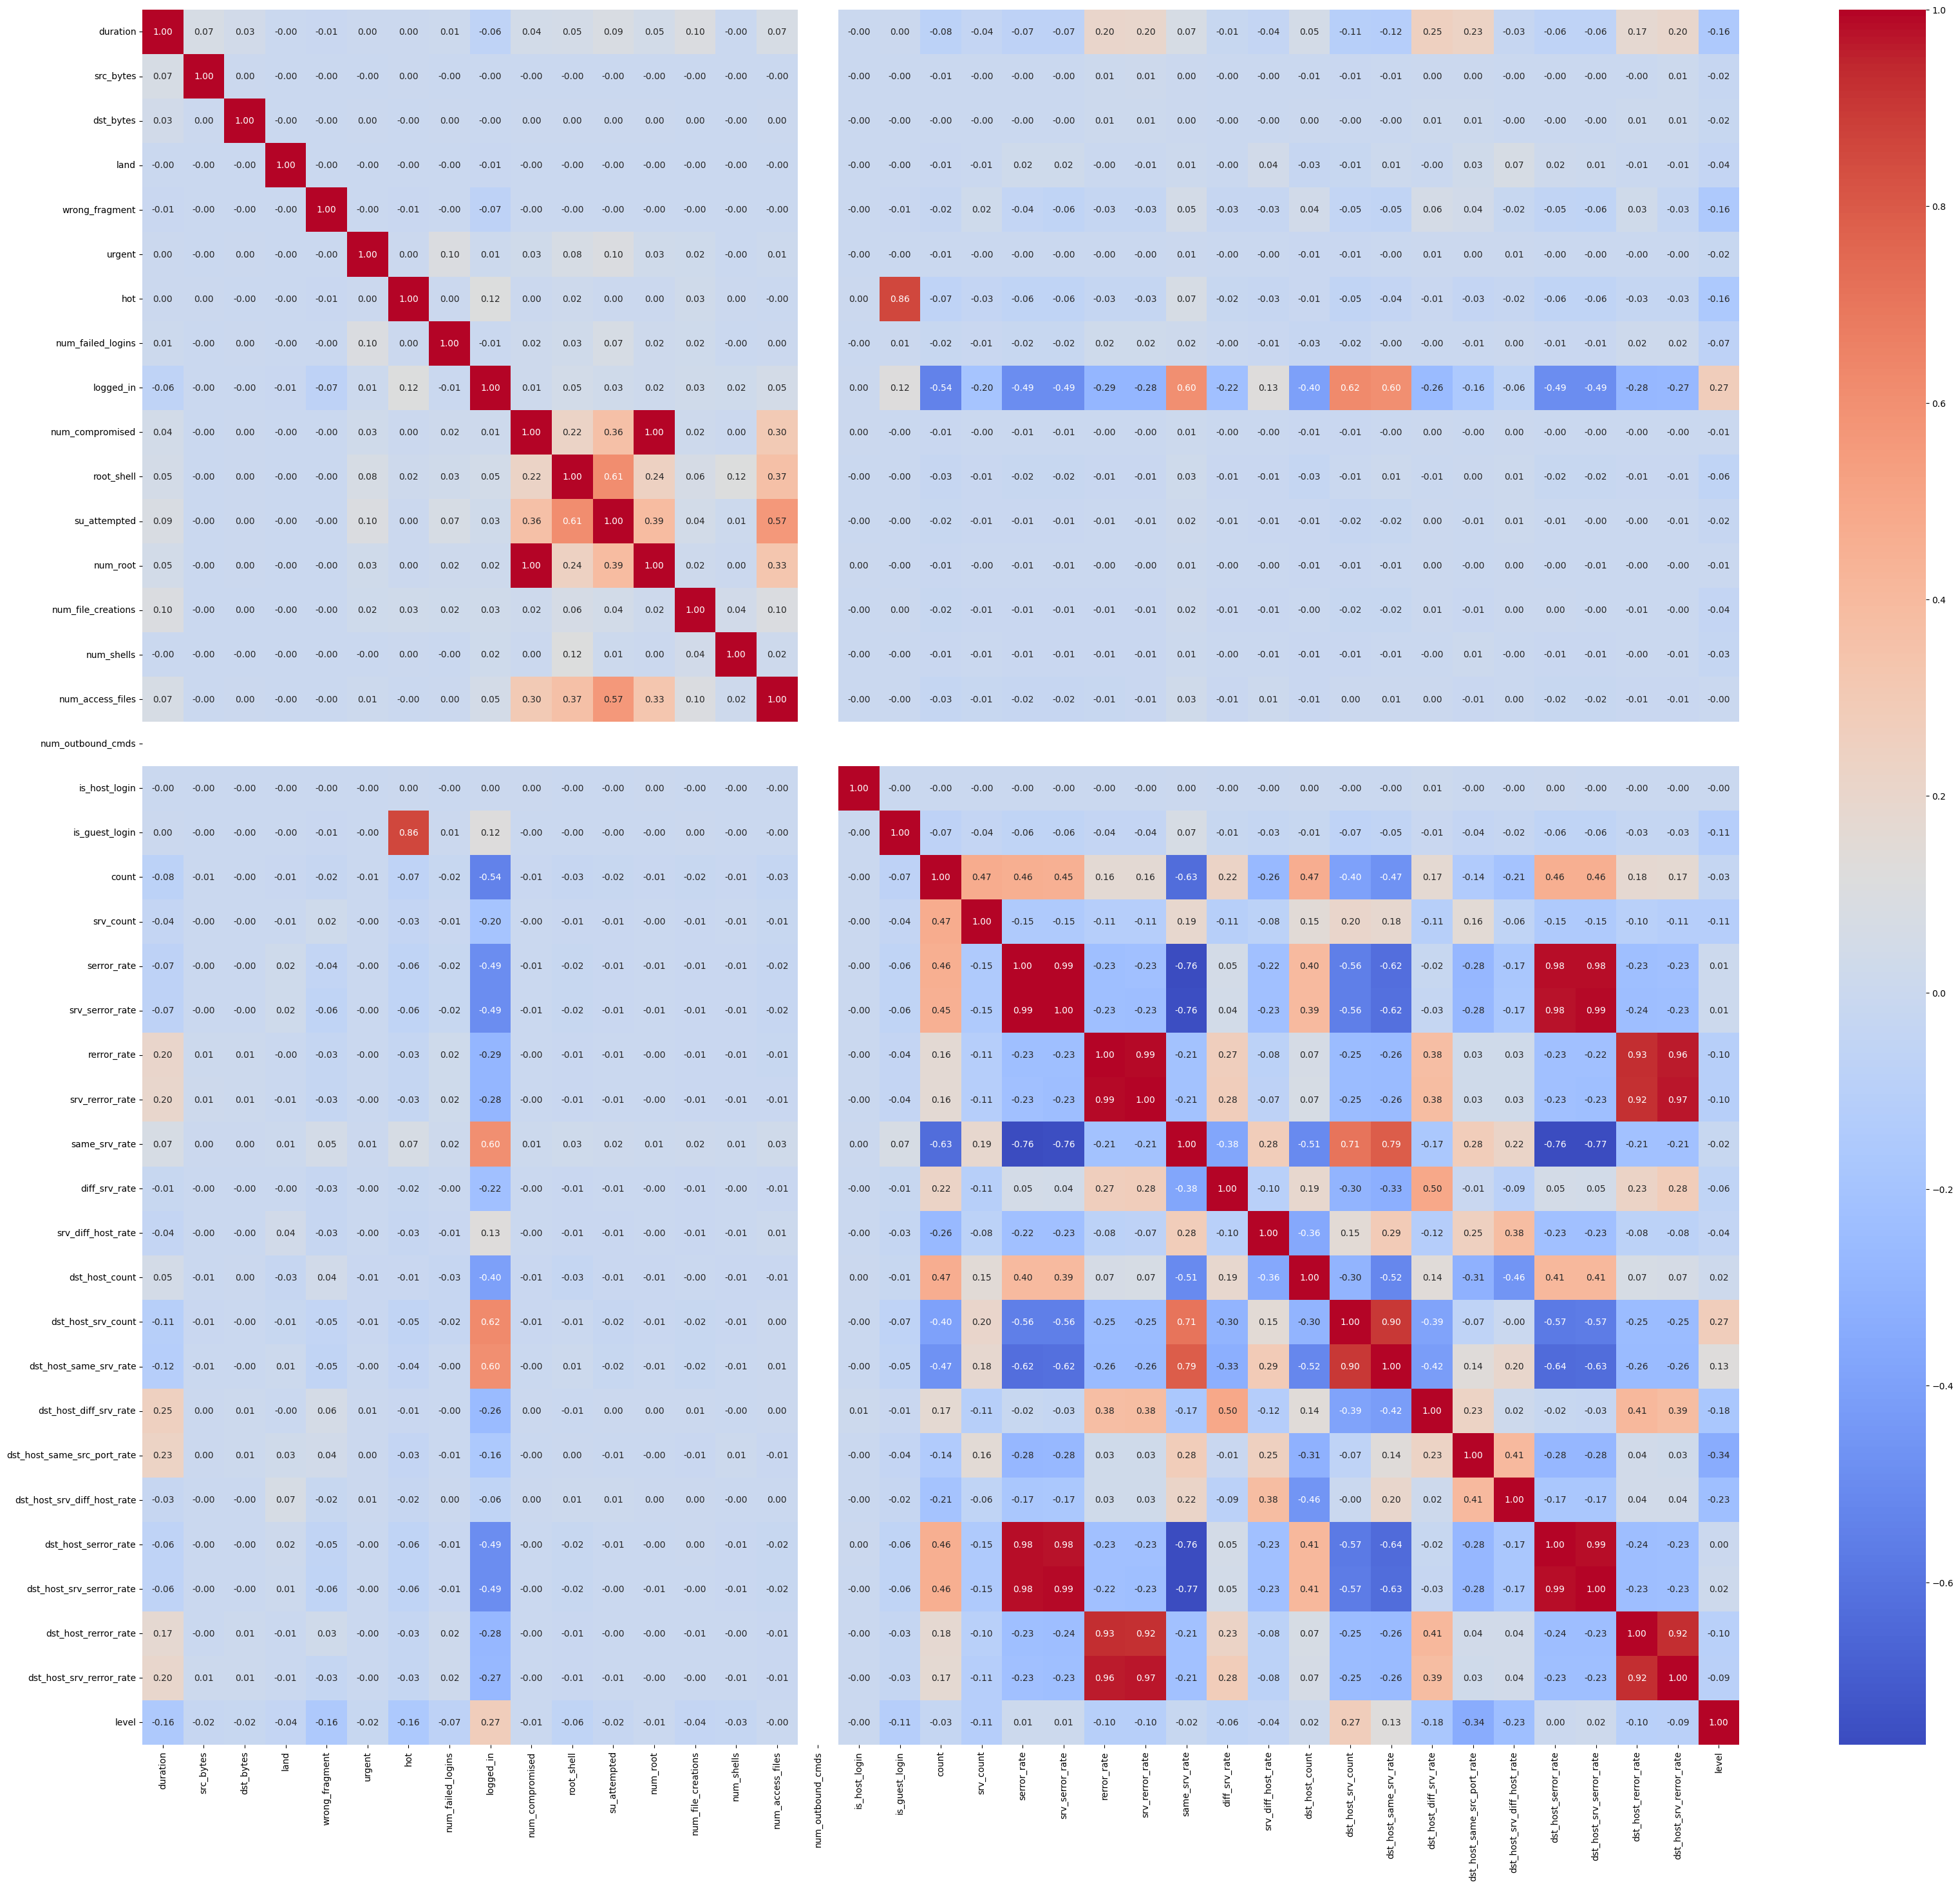

In [22]:
plt.figure(figsize=(40, 35))

# Select only numeric columns
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

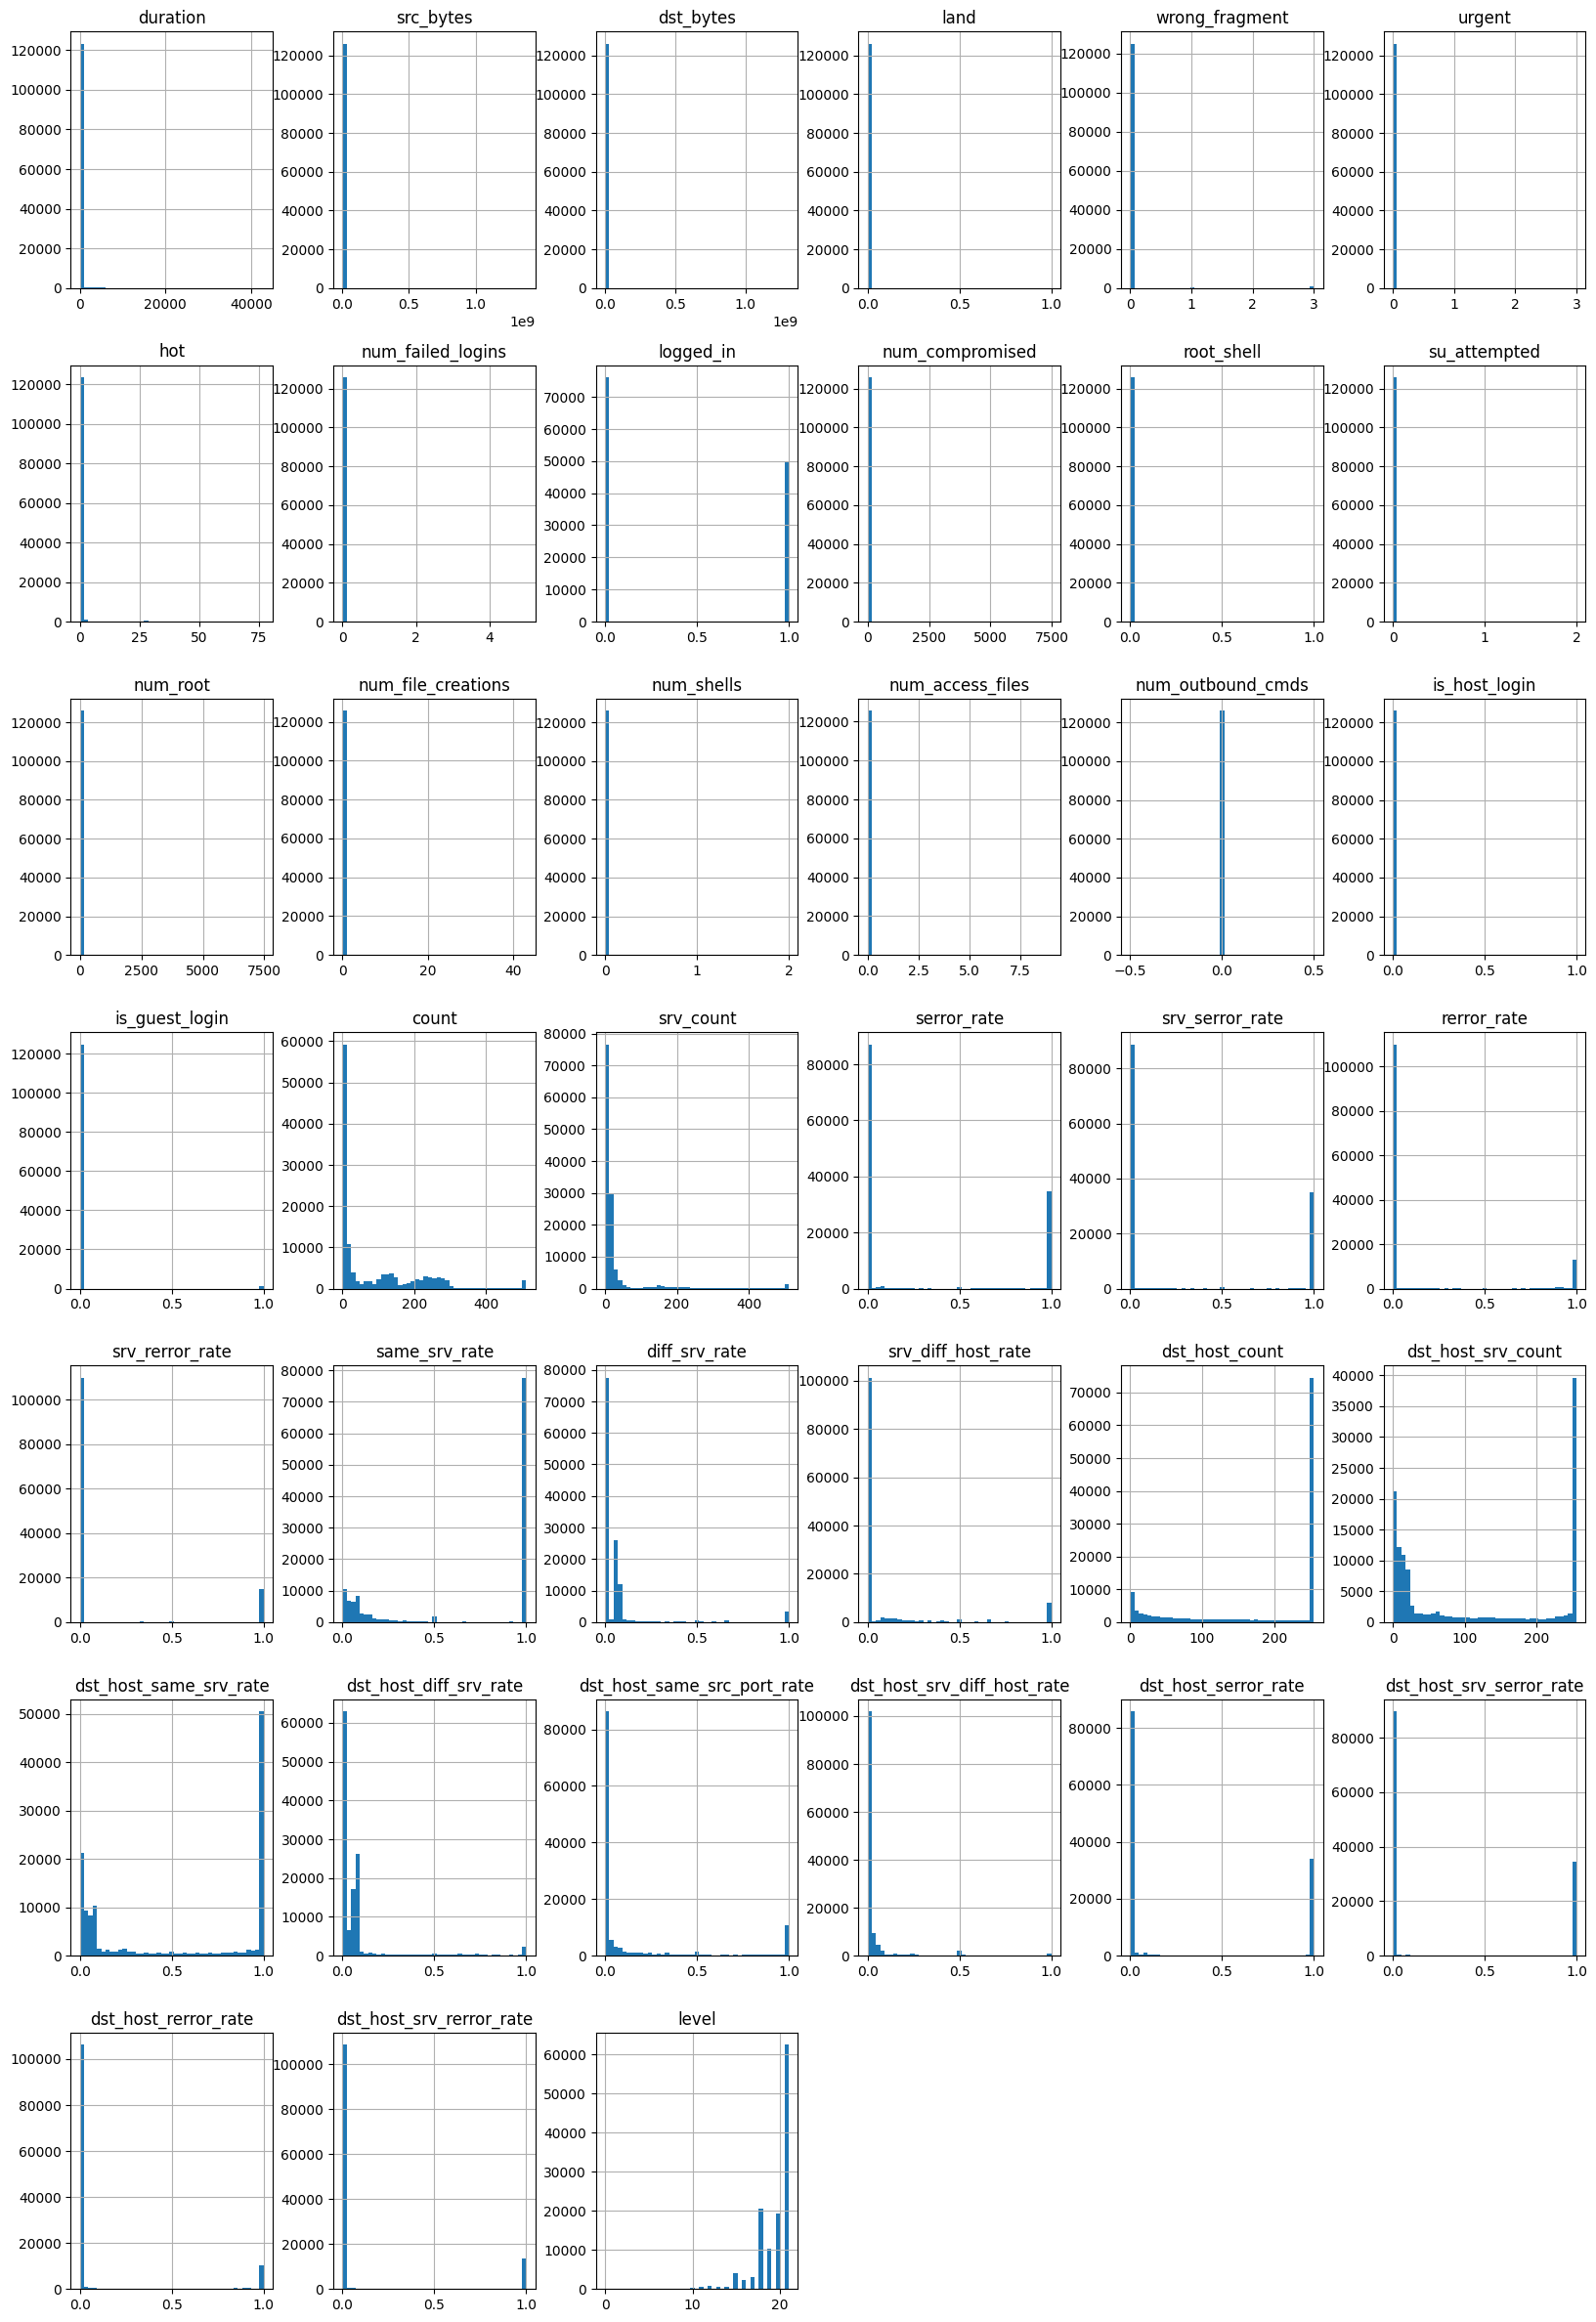

In [ ]:
# Plot histograms for all features in the dataset
df.hist(bins=43, figsize=(20, 30))

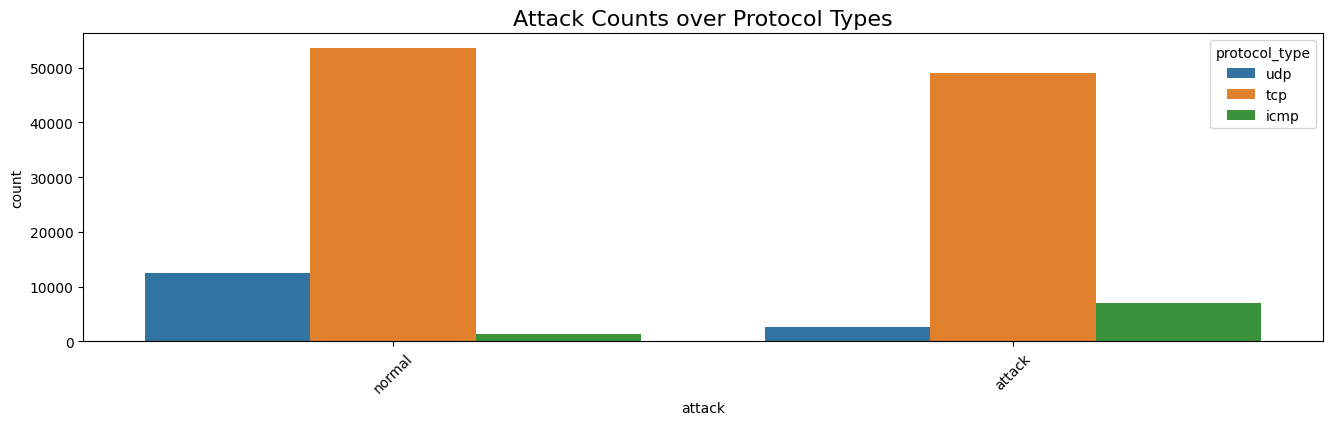

In [16]:
# Set figure size
plt.figure(figsize=(16, 4))

# Create a count plot of attack types grouped by protocol type
sns.countplot(x='attack', data=df, hue='protocol_type')

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Set plot title
plt.title('Attack Counts over Protocol Types', fontdict={'fontsize': 16})

# Show the plot
plt.show()

In [18]:
# Display the relative frequency (as proportions) of each protocol type
df["protocol_type"].value_counts(normalize=True)

protocol_type
tcp    0.815
udp    0.119
icmp   0.066
Name: proportion, dtype: float64

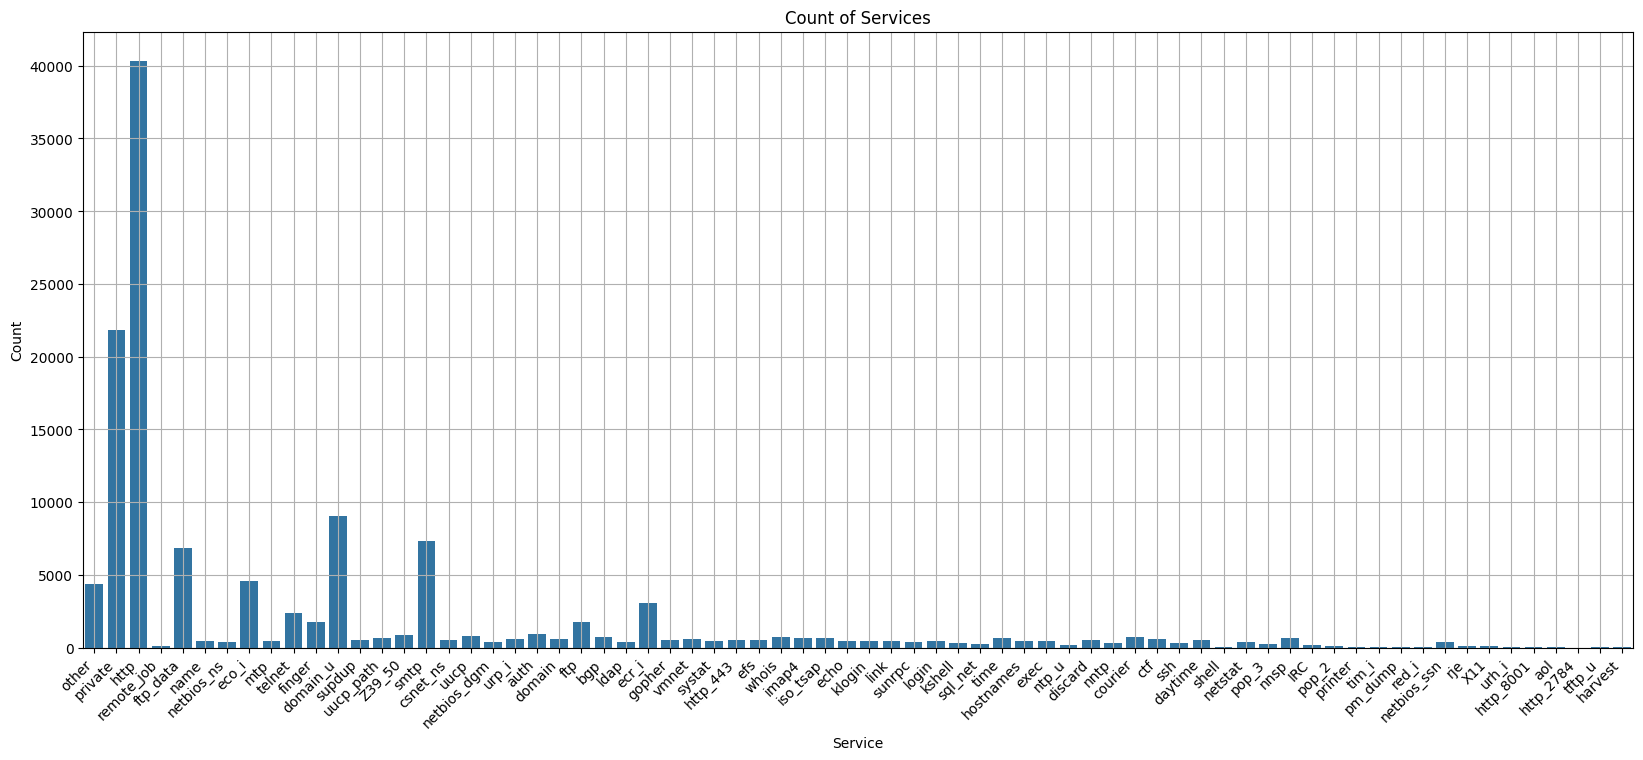

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size for better visibility
plt.figure(figsize=(20, 8))

# Create a count plot of the 'service' feature
ax = sns.countplot(x='service', data=df)

# Rotate x-axis labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Label axes and add title
plt.xlabel('Service')
plt.ylabel('Count')
plt.title('Count of Services')

# Add gridlines for visual reference
plt.grid(True)

# Display the plot
plt.show()

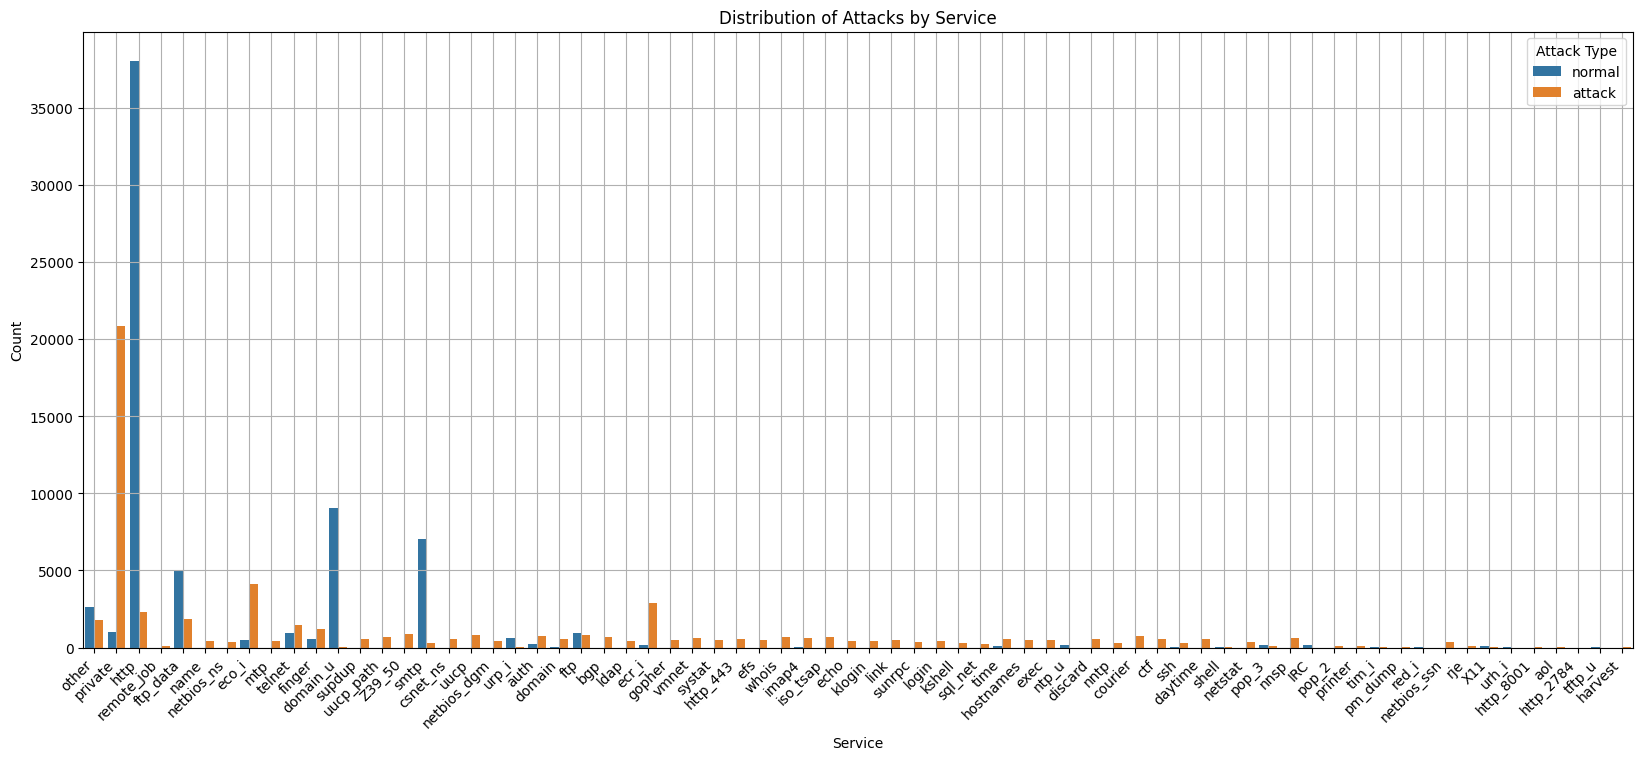

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size for wide view
plt.figure(figsize=(20, 8))

# Create a count plot showing attack vs normal traffic per service
ax = sns.countplot(x='service', hue='attack', data=df)

# Rotate x-axis labels for clarity
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Label the axes and add a title
plt.xlabel('Service')
plt.ylabel('Count')
plt.title('Distribution of Attacks by Service')

# Add legend and grid for better readability
plt.legend(title='Attack Type')
plt.grid(True)

# Show the plot
plt.show()